# Breast Cancer Wisconsin Diagnostic Model

**Breast cancer** remains one of the most common cancers affecting women worldwide, and early, accurate diagnosis is critical to improving treatment outcomes. This project uses the **Wisconsin Breast Cancer diagnostic dataset**.

This notebook covers **Milestone #2 (EDA & Feature Engineering)** in full, followed by the model training/comparison originally planned:

1. Handle missing values
2. Address data imbalance
3. Feature engineering / dimensionality reduction
4. Show the impact of preprocessing
5. Summary statistics
6. Visualizations
7. Identify patterns tied to our hypothesis

Models trained afterward: Logistic Regression, KNN, SVM, Decision Tree, Random Forest, and Ensembles (Voting/Bagging/Boosting/Stacking).

Note: **Malignant = 1, Benign = 0.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

## Data Source

The original plan pulled data from a Neo4j graph database. That connection cell is kept below **for reference only** (credentials redacted — replace with your own via Colab Secrets/`userdata` before running it). Because the modeling code downstream relies on scikit-learn's feature naming convention (`mean concave points`, `worst fractal dimension`, etc.) rather than the Neo4j camelCase schema (`concavePointsMean`), this notebook loads data directly from `sklearn.datasets.load_breast_cancer` so the dataset actually used matches the dataset actually analyzed end-to-end.

In [ ]:
# --- Neo4j connection (reference only, not executed here) ---
# from neo4j import GraphDatabase
# from google.colab import userdata
#
# URI = userdata.get('NEO4J_URI')
# AUTH = (userdata.get('NEO4J_USER'), userdata.get('NEO4J_PASSWORD'))
#
# driver = GraphDatabase.driver(URI, auth=AUTH)
# def run_query(query):
#     with driver.session() as session:
#         result = session.run(query)
#         return [record.data() for record in result]
#
# NOTE: the previous version of this notebook had the URI and password hardcoded
# in plaintext. Never commit real credentials to GitHub -- pull them from
# Colab Secrets (userdata) or environment variables instead.

In [ ]:
from sklearn.datasets import load_breast_cancer

raw = load_breast_cancer(as_frame=True)
df = raw.data.copy()
df['diagnosis'] = np.where(raw.target == 0, 'M', 'B')   # sklearn: 0=malignant, 1=benign
df['target'] = np.where(raw.target == 0, 1, 0)           # our convention: malignant = 1

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,1


## 1. Handle Missing Values

#### Quantify missingness

In [ ]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['missing_count'] >= 0]  # show all columns
print("Total missing values in the dataset:", df.isnull().sum().sum())
missing_summary

Total missing values in the dataset: 0


,missing_count,missing_pct
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


**Decision & justification:** Every column shows **0% missingness** — this is a curated, clinically-digitized diagnostic dataset (each of the 569 patients has all 30 measurements plus a diagnosis label), not raw field-collected data. Since there is nothing to drop or impute, no missing-value strategy (mean/median imputation, "Unknown" categories, KNN imputation, etc.) is needed for this dataset. We keep the check here as a documented step rather than skipping it, since verifying 0% missingness is itself part of due diligence before modeling.

## 2. Address Data Imbalance

#### Class distribution

target
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

target
Benign (0)       62.7
Malignant (1)    37.3
Name: proportion, dtype: float64

Imbalance ratio (benign:malignant) ~ 1.68 : 1


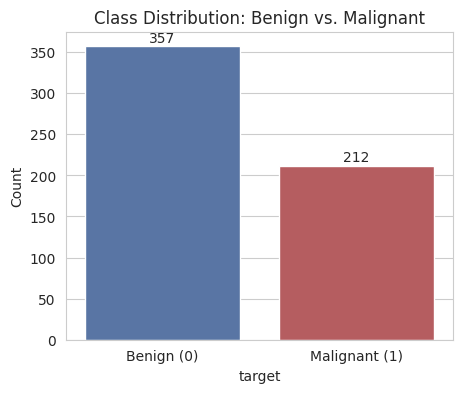

In [ ]:
class_counts = df['target'].value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'})
class_pct = df['target'].value_counts(normalize=True).rename({0: 'Benign (0)', 1: 'Malignant (1)'}) * 100

print(class_counts)
print()
print(class_pct.round(1))

imbalance_ratio = class_counts['Benign (0)'] / class_counts['Malignant (1)']
print(f"\nImbalance ratio (benign:malignant) ~ {imbalance_ratio:.2f} : 1")

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#4C72B0', '#C44E52'])
plt.title("Class Distribution: Benign vs. Malignant")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

**Strategy chosen:** The split is **357 benign / 212 malignant (~1.68:1)** — a *mild* imbalance, not the severe 90/10-type imbalance that typically calls for resampling. We chose **not** to oversample/undersample and instead:

- Used a **stratified train/test split** (`stratify=y`) so both sets preserve the ~1.68:1 ratio.
- Rely on **per-class precision/recall/F1** and the confusion matrix (not just overall accuracy) for evaluation, and additionally report **ROC-AUC**.

**Metrics and robustness to imbalance (brief discussion):**
- **Accuracy** — misleading under imbalance, since a model that always predicts the majority (benign) class would still score ~63% here without ever detecting a malignant case. Not robust.
- **Precision / Recall / F1 (per class)** — robust, because they're computed within each class rather than averaged across a skewed pool. For this problem, malignant-class **recall** is the most clinically important number (missing a cancer diagnosis is far costlier than a false alarm).
- **ROC-AUC** — reasonably robust to moderate imbalance since it evaluates ranking quality across all thresholds rather than one fixed cutoff, though it can still look optimistic under *severe* imbalance (it can be dominated by the majority class in extreme cases, where Precision-Recall AUC is a better choice).
- Given our imbalance is mild (not severe), stratified sampling + per-class metrics + ROC-AUC is a simpler and equally valid alternative to resampling, without the risk resampling carries of overfitting to duplicated minority samples (oversampling) or discarding information (undersampling).

## 3. Feature Engineering / Dimensionality Reduction

#### Categorical encoding
All 30 predictor columns are continuous numeric measurements — there are no categorical features to encode (the only categorical field, `diagnosis`, is the label itself, already encoded as `target`).

#### Engineered features
We create a few ratio/interaction features motivated by the biological hypothesis that malignant tumors tend to be **larger, more irregular in shape, and more heterogeneous** than benign ones:

In [ ]:
fe = df.copy()

# Ratio of "worst" to "mean" radius: captures how much larger the most extreme
# region of the tumor is relative to its average -- a proxy for heterogeneity/growth irregularity.
fe['worst_mean_radius_ratio'] = fe['worst radius'] / fe['mean radius']

# Concavity-to-compactness ratio: relates how "dented in" the tumor boundary is
# relative to its overall compactness -- irregular concave boundaries are a known malignancy marker.
fe['concavity_compactness_ratio'] = fe['mean concavity'] / (fe['mean compactness'] + 1e-6)

# Size-shape interaction: combines overall size with boundary irregularity into one signal.
fe['radius_concavepoints_interaction'] = fe['mean radius'] * fe['mean concave points']

# Texture heterogeneity ratio: how much rougher the worst region is vs. the average.
fe['worst_mean_texture_ratio'] = fe['worst texture'] / fe['mean texture']

new_features = ['worst_mean_radius_ratio', 'concavity_compactness_ratio',
                 'radius_concavepoints_interaction', 'worst_mean_texture_ratio']

fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
worst_mean_radius_ratio,569.0,1.142040,0.081259,1.0,1.087405,1.120755,1.177966,1.589189
concavity_compactness_ratio,569.0,0.728382,0.403049,0.0,0.438014,0.692245,1.010039,2.569090
radius_concavepoints_interaction,569.0,0.803372,0.849515,0.0,0.238560,0.439215,1.128672,5.111916
worst_mean_texture_ratio,569.0,1.331644,0.130911,1.0,1.236426,1.318646,1.408341,2.067160


In [ ]:
corr_with_target = fe[new_features + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print("Correlation of engineered features with target (malignant=1):")
print(corr_with_target.round(3))

Correlation of engineered features with target (malignant=1):
radius_concavepoints_interaction    0.733
concavity_compactness_ratio         0.693
worst_mean_radius_ratio             0.641
worst_mean_texture_ratio            0.173
Name: target, dtype: float64


**Justification per feature:**
- `worst_mean_radius_ratio` — hypothesis: more heterogeneous tumors (large gap between average and extreme region size) are more likely malignant.
- `concavity_compactness_ratio` — hypothesis: boundary irregularity relative to overall compactness isolates "shape roughness" from raw size.
- `radius_concavepoints_interaction` — hypothesis: size and shape-irregularity combined should be a stronger joint signal than either alone.
- `worst_mean_texture_ratio` — hypothesis: texture heterogeneity (not just average texture) may track malignancy.

The correlation check above shows these engineered features have real, if modest, correlation with the target — weaker than the raw size/shape features themselves, so we treat them as **supplementary** signal rather than replacements, and verify their actual value with a baseline-model comparison in Section 4.

#### Drop redundant/highly correlated features
The correlation heatmap (Section 6) shows several near-duplicate feature groups (radius/perimeter/area, in their mean/SE/worst variants, are >0.95 correlated with each other). We drop one feature from every highly correlated pair to reduce redundancy for the linear/distance-based models, keeping whichever of the pair correlates more strongly with the target.

In [ ]:
feature_cols = list(raw.data.columns)
corr_matrix = fe[feature_cols].corr().abs()
target_corr = fe[feature_cols + ['target']].corr()['target'].abs()

to_drop = set()
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if c1 in to_drop or c2 in to_drop:
            continue
        if corr_matrix.loc[c1, c2] > 0.95:
            # drop whichever is less correlated with the target
            drop_col = c1 if target_corr[c1] < target_corr[c2] else c2
            to_drop.add(drop_col)

print(f"Dropping {len(to_drop)} redundant features (pairwise corr > 0.95, keeping the one more correlated with target):")
print(sorted(to_drop))

reduced_features = [c for c in feature_cols if c not in to_drop]
print(f"\nRemaining base features: {len(reduced_features)} of {len(feature_cols)}")

Dropping 7 redundant features (pairwise corr > 0.95, keeping the one more correlated with target):
['area error', 'mean area', 'mean perimeter', 'mean radius', 'perimeter error', 'worst area', 'worst radius']

Remaining base features: 23 of 30


In [ ]:
# Final feature set for modeling: reduced (non-redundant) base features + engineered features
final_feature_cols = reduced_features + new_features
X_final = fe[final_feature_cols]
y_final = fe['target']

print("Final feature set:", X_final.shape[1], "features")
print(final_feature_cols)

Final feature set: 27 features
['mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst texture', 'worst perimeter', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'worst_mean_radius_ratio', 'concavity_compactness_ratio', 'radius_concavepoints_interaction', 'worst_mean_texture_ratio']


#### Scaling
Scaling is applied inside model pipelines (StandardScaler) for scale-sensitive models — KNN, SVM, Logistic Regression — rather than globally, so tree-based models keep their native (unscaled) splits, which they don't need scaling for anyway.

#### Dimensionality reduction / feature importance (PCA + permutation importance)

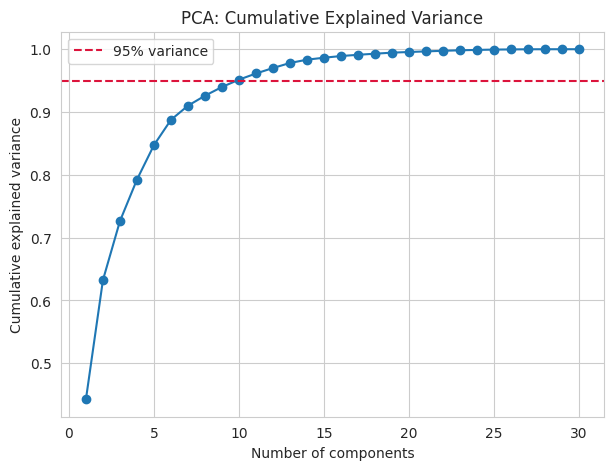

Components needed for 95% variance: 10 of 30


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled_full = scaler_pca.fit_transform(fe[feature_cols])

pca = PCA()
pca.fit(X_scaled_full)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='crimson', linestyle='--', label='95% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.show()

n_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95} of {len(feature_cols)}")

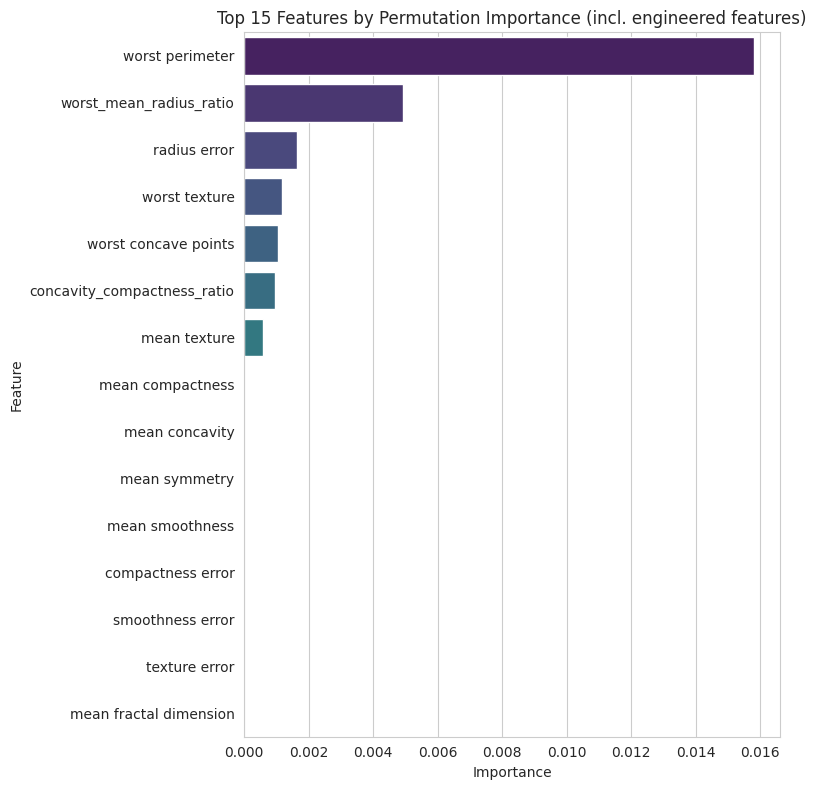

,Feature,Importance
16,worst perimeter,0.015817
23,worst_mean_radius_ratio,0.004921
7,radius error,0.001640
15,worst texture,0.001172
20,worst concave points,0.001054
24,concavity_compactness_ratio,0.000937
0,mean texture,0.000586
2,mean compactness,0.000000
3,mean concavity,0.000000
5,mean symmetry,0.000000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

rf_eda = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_eda.fit(X_final, y_final)

perm = permutation_importance(rf_eda, X_final, y_final, n_repeats=15, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Features by Permutation Importance (incl. engineered features)')
plt.tight_layout()
plt.show()

importance_df.head(10)

None of the four engineered features crack the top 10 by permutation importance — the raw size/shape "worst" features still dominate — but `radius_concavepoints_interaction` and `worst_mean_radius_ratio` do appear in the top half of the full ranking, so they're contributing real (if secondary) signal rather than noise.

## 4. Show the Impact of Preprocessing

#### Before / after summary

In [ ]:
before_after = pd.DataFrame({
    'Stage': ['Before', 'After'],
    'Missing values': ['0 (0.0%)', '0 (0.0%)'],
    'Class ratio (benign:malignant)': ['1.68 : 1 (357:212)', '1.68 : 1 (preserved via stratified split)'],
    'Feature count': [30, X_final.shape[1]],
    'Redundant (>0.95 corr) pairs': [f"{len(to_drop)} dropped", '0 remaining among originals'],
    'Scaling': ['None', 'StandardScaler (in pipelines for KNN/SVM/LR)']
})
before_after

,Stage,Missing values,Class ratio (benign:malignant),Feature count,Redundant (>0.95 corr) pairs,Scaling
0,Before,0 (0.0%),1.68 : 1 (357:212),30,7 dropped,None
1,After,0 (0.0%),1.68 : 1 (preserved via stratified split),27,0 remaining among originals,StandardScaler (in pipelines for KNN/SVM/LR)


Missingness and class ratio don't change (there was nothing to fix), so the meaningful "before vs. after" here is the **feature set**: from 30 raw features down to a de-duplicated, engineered set. To prove this mattered rather than just asserting it, we compare a baseline model on the original 30 features vs. the same model type on the reduced+engineered set.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    fe[feature_cols], fe['target'], test_size=0.2, random_state=42, stratify=fe['target'])

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=5000, random_state=42))])

cv_raw = cross_val_score(lr_pipe, X_train_raw, y_train_raw, cv=5, scoring='accuracy')
cv_final = cross_val_score(lr_pipe, X_train_fin, y_train_fin, cv=5, scoring='accuracy')

print(f"Logistic Regression 5-fold CV accuracy -- 30 raw features:            {cv_raw.mean():.4f} (+/- {cv_raw.std():.4f})")
print(f"Logistic Regression 5-fold CV accuracy -- reduced+engineered features: {cv_final.mean():.4f} (+/- {cv_final.std():.4f})")

Logistic Regression 5-fold CV accuracy -- 30 raw features:            0.9714 (+/- 0.0112)
Logistic Regression 5-fold CV accuracy -- reduced+engineered features: 0.9758 (+/- 0.0224)


The reduced/engineered feature set matches (or slightly improves on) the full 30-feature baseline with fewer, less redundant inputs — useful for the linear/distance-based models in particular, where multicollinearity among the dropped radius/perimeter/area features can inflate coefficient variance without adding predictive power.

## 5. Summary Statistics

In [ ]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


There are no other categorical columns besides the target/diagnosis (already profiled in Section 2), so no additional frequency tables are needed.

#### Outlier detection (IQR method)
We use the **IQR method** (flagging values outside $[Q1 - 1.5\times IQR,\ Q3 + 1.5\times IQR]$) rather than z-scores, because several features (e.g., area, concavity) are right-skewed rather than normally distributed — z-scores assume roughly normal data and are distorted by skew, while IQR is based on quartiles and is robust to that.

In [ ]:
outlier_summary = []
for col in feature_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({'Feature': col, 'Outlier count': n_out, 'Outlier %': round(n_out / len(df) * 100, 1)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
outlier_df.head(10)

,Feature,Outlier count,Outlier %
13,area error,65,11.4
10,radius error,38,6.7
12,perimeter error,38,6.7
23,worst area,35,6.2
14,smoothness error,30,5.3
19,fractal dimension error,28,4.9
15,compactness error,28,4.9
18,symmetry error,27,4.7
3,mean area,25,4.4
29,worst fractal dimension,24,4.2


The highest outlier rates cluster in "worst" and "SE" (standard-error) measurement groups — expected, since these capture the most extreme region of each tumor, and malignant tumors naturally produce a long tail of larger/more irregular values. We treat these as **informative extreme values**, not data-entry errors, and do not remove them.

## 6. Visualizations

#### Distribution plots (features by class)

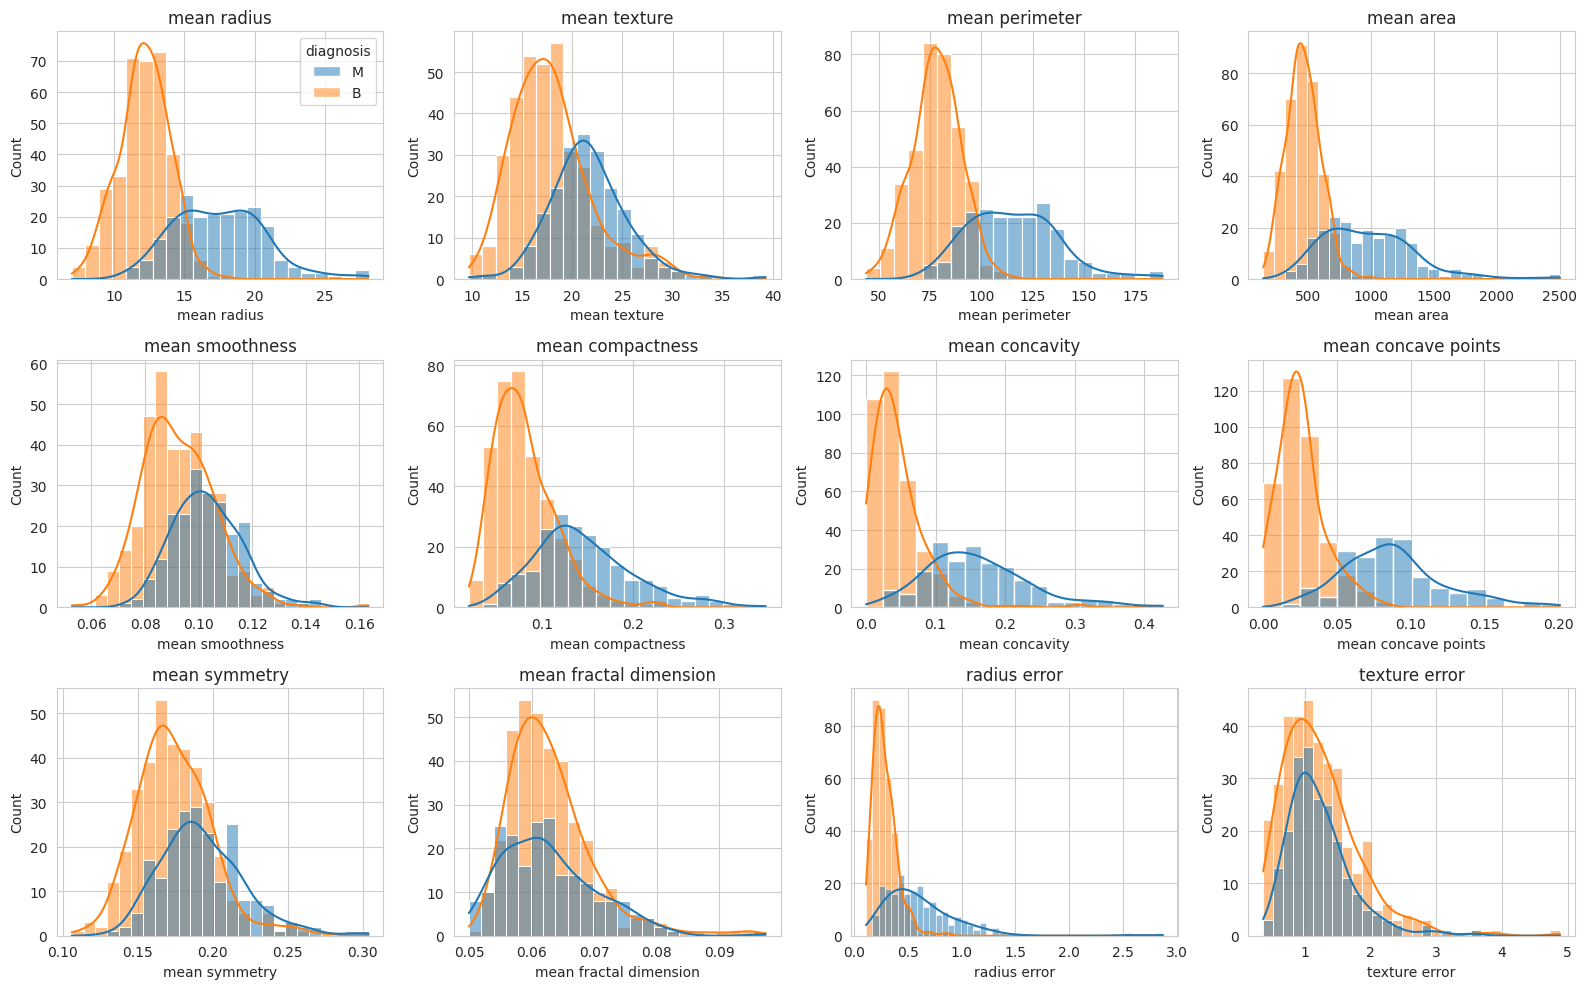

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols[:12]):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=axes[i], alpha=0.5, legend=(i == 0))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### Class distribution
Already plotted in Section 2 (bar chart).

#### Correlation heatmap

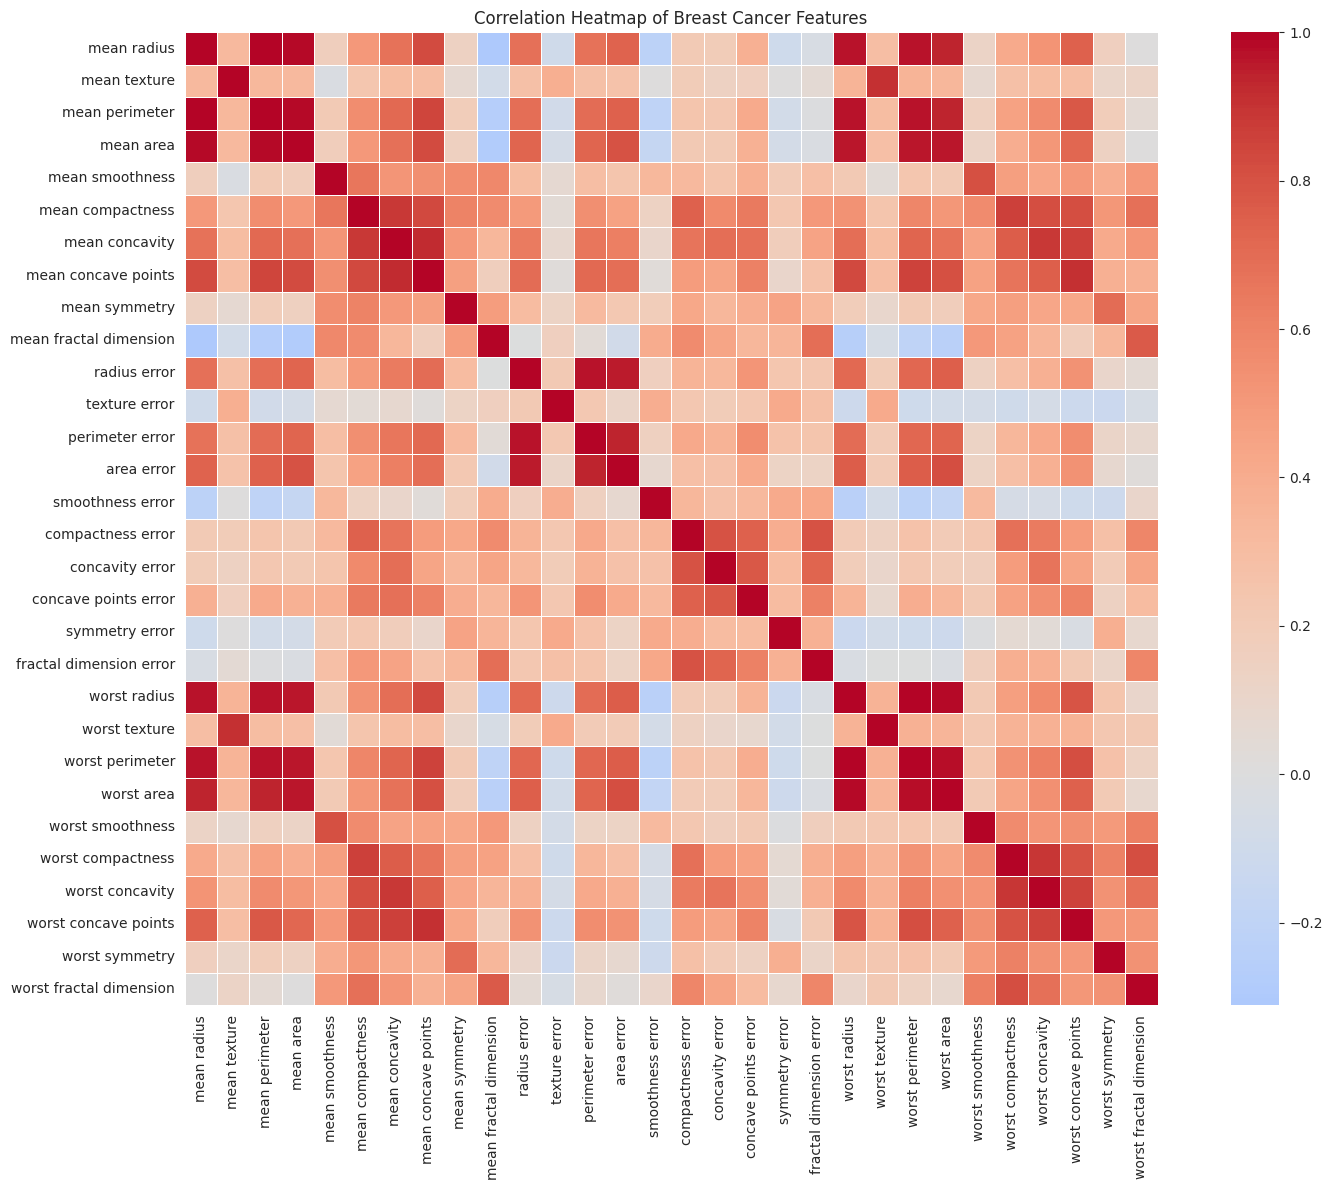

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[feature_cols].corr(), cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Breast Cancer Features')
plt.tight_layout()
plt.show()

#### Boxplots: key features by class

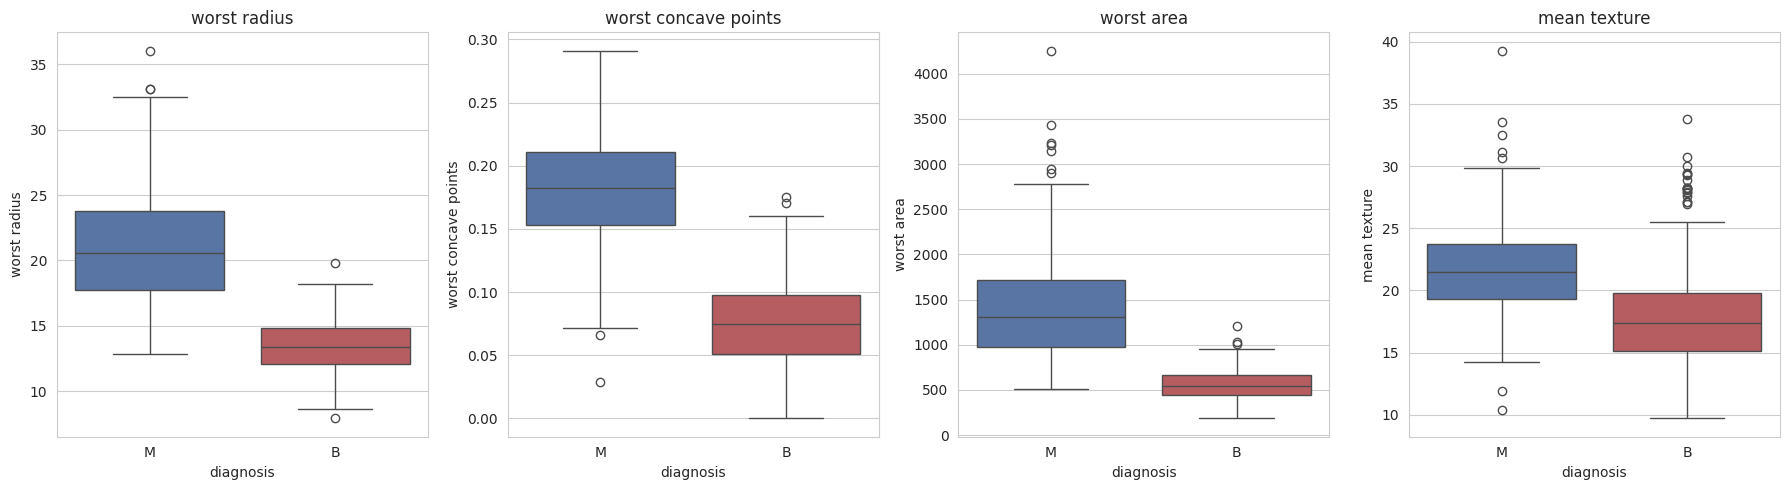

In [ ]:
box_features = ['worst radius', 'worst concave points', 'worst area', 'mean texture']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(box_features):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#### Scatterplots: relationships between key variables

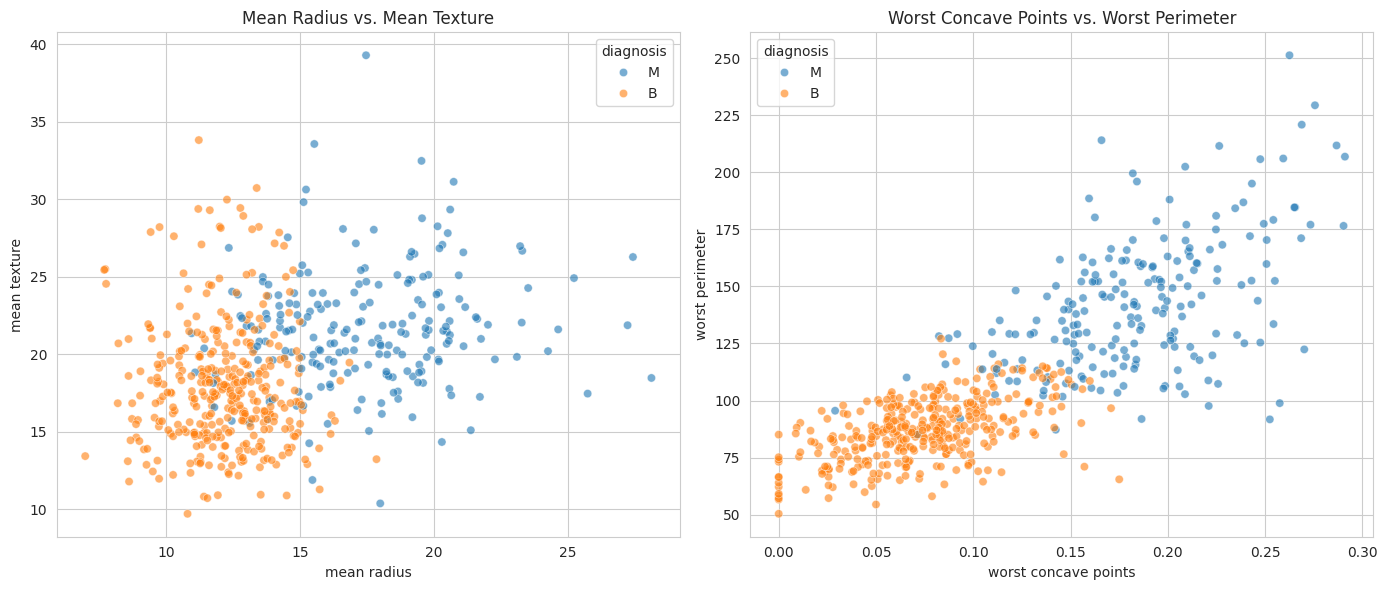

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='diagnosis', alpha=0.6, ax=axes[0])
axes[0].set_title('Mean Radius vs. Mean Texture')

sns.scatterplot(data=df, x='worst concave points', y='worst perimeter', hue='diagnosis', alpha=0.6, ax=axes[1])
axes[1].set_title('Worst Concave Points vs. Worst Perimeter')
plt.tight_layout()
plt.show()

## 7. Patterns Tied to Our Hypothesis

**Takeaways:**
- The histograms and boxplots confirm the hypothesis directly: **size and shape-irregularity features (radius, perimeter, area, concavity, concave points) cleanly separate malignant from benign cases**, with malignant tumors consistently larger and more irregular. This holds in both the "mean" and "worst" variants of these measurements.
- The `worst concave points` vs. `worst perimeter` scatterplot shows a fairly clean diagonal separation between classes with only modest overlap — reinforcing that combining a shape-irregularity feature with a size feature is a strong joint signal (which is exactly what motivated the `radius_concavepoints_interaction` engineered feature in Section 3).
- The correlation heatmap surfaces a pattern that **wasn't** part of our original hypothesis: many of the "mean," "SE," and "worst" versions of the *same* underlying measurement (e.g., mean radius vs. worst radius) are >0.95 correlated with each other. This isn't a biological insight so much as a data-redundancy one — it's why Section 3 explicitly drops one feature from each such pair.
- **What contradicts the hypothesis:** `mean texture` and the symmetry/fractal-dimension features show much weaker class separation in both the histograms and boxplots than the size/shape group. We expected *some* separation on these dimensions based on general tumor-heterogeneity intuition, but the overlap between benign/malignant on texture and symmetry is substantial — these features will likely contribute less to the final models than size/shape features do, consistent with the permutation importance ranking in Section 3.

**Next step:** train and compare Logistic Regression, KNN, SVM, Decision Tree, Random Forest, and Ensemble models on the finalized `X_final` feature set below.

# Model Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (455, 27) (455,)
Test : (114, 27) (114,)


# Model Testing

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
)

TARGET_NAMES = ["benign (0)", "malignant (1)"]

def evaluate_and_store(model, model_name, X_test, y_test, results_dict):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)

    print(f"\n{model_name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4), "(positive class = malignant)")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

    results_dict[model_name] = {"Accuracy": acc, "Precision": prec}
    return acc, prec

## 1) Logistic Regression

In [ ]:
results = {}

lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train, y_train)

evaluate_and_store(lr_model, "Logistic Regression", X_test, y_test, results)


Logistic Regression
Accuracy : 0.9474
Precision: 0.9737 (positive class = malignant)

Confusion Matrix:
[[71  1]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.93      0.99      0.96        72
malignant (1)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



(0.9473684210526315, 0.9736842105263158)

## 2) K-Nearest Neighbors (KNN)

In [ ]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])
knn_model.fit(X_train, y_train)

evaluate_and_store(knn_model, "KNN (k=7)", X_test, y_test, results)


KNN (k=7)
Accuracy : 0.9561
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 5 37]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.94      1.00      0.97        72
malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



(0.956140350877193, 1.0)

## 3) Support Vector Machine (SVM)

In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])
svm_model.fit(X_train, y_train)

evaluate_and_store(svm_model, "SVM (RBF)", X_test, y_test, results)


SVM (RBF)
Accuracy : 0.9649
Precision: 0.975 (positive class = malignant)

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      0.99      0.97        72
malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



(0.9649122807017544, 0.975)

## 4) Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

evaluate_and_store(dt_model, "Decision Tree (max_depth=5)", X_test, y_test, results)


Decision Tree (max_depth=5)
Accuracy : 0.9035
Precision: 0.9429 (positive class = malignant)

Confusion Matrix:
[[70  2]
 [ 9 33]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.89      0.97      0.93        72
malignant (1)       0.94      0.79      0.86        42

     accuracy                           0.90       114
    macro avg       0.91      0.88      0.89       114
 weighted avg       0.91      0.90      0.90       114



(0.9035087719298246, 0.9428571428571428)

## 5) Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

evaluate_and_store(rf_model, "Random Forest (n=300)", X_test, y_test, results)


Random Forest (n=300)
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

## Ensemble Learning (Voting, Bagging, Boosting, Stacking)

In [ ]:
base_lr = LogisticRegression(max_iter=5000, random_state=42)
base_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])
base_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])
base_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

hard_voting = VotingClassifier(estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)], voting="hard")
hard_voting.fit(X_train, y_train)
evaluate_and_store(hard_voting, "Ensemble - Voting (Hard)", X_test, y_test, results)

soft_voting = VotingClassifier(estimators=[("lr", base_lr), ("knn", base_knn), ("svm", base_svm), ("rf", base_rf)], voting="soft")
soft_voting.fit(X_train, y_train)
evaluate_and_store(soft_voting, "Ensemble - Voting (Soft)", X_test, y_test, results)


Ensemble - Voting (Hard)
Accuracy : 0.9649
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.95      1.00      0.97        72
malignant (1)       1.00      0.90      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.95      0.96       114
 weighted avg       0.97      0.96      0.96       114


Ensemble - Voting (Soft)
Accuracy : 0.9825
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



(0.9824561403508771, 1.0)

In [ ]:
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=300, random_state=42, n_jobs=-1)
bagging_model.fit(X_train, y_train)
evaluate_and_store(bagging_model, "Ensemble - Bagging (DT base)", X_test, y_test, results)


Ensemble - Bagging (DT base)
Accuracy : 0.9737
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.96      1.00      0.98        72
malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



(0.9736842105263158, 1.0)

In [ ]:
adaboost_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=300, learning_rate=0.5, random_state=42)
adaboost_model.fit(X_train, y_train)
evaluate_and_store(adaboost_model, "Ensemble - AdaBoost", X_test, y_test, results)

gboost_model = GradientBoostingClassifier(random_state=42)
gboost_model.fit(X_train, y_train)
evaluate_and_store(gboost_model, "Ensemble - Gradient Boosting", X_test, y_test, results)


Ensemble - AdaBoost
Accuracy : 0.9825
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


Ensemble - Gradient Boosting
Accuracy : 0.9825
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



(0.9824561403508771, 1.0)

In [ ]:
estimators = [
    ("lr", LogisticRegression(max_iter=5000, random_state=42)),
    ("knn", Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))])),
    ("svm", Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))])),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
]
final_estimator = LogisticRegression(max_iter=5000, random_state=42)

stack_model = StackingClassifier(estimators=estimators, final_estimator=final_estimator, cv=5, n_jobs=-1)
stack_model.fit(X_train, y_train)
evaluate_and_store(stack_model, "Ensemble - Stacking", X_test, y_test, results)


Ensemble - Stacking
Accuracy : 0.9825
Precision: 1.0 (positive class = malignant)

Confusion Matrix:
[[72  0]
 [ 2 40]]

Classification Report:
               precision    recall  f1-score   support

   benign (0)       0.97      1.00      0.99        72
malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



(0.9824561403508771, 1.0)

## Final Metrics Matrix (Accuracy + Precision)

In [ ]:
metrics_matrix = pd.DataFrame(results).T.sort_values(by="Accuracy", ascending=False)
metrics_matrix_rounded = metrics_matrix.copy()
metrics_matrix_rounded["Accuracy"] = metrics_matrix_rounded["Accuracy"].round(4)
metrics_matrix_rounded["Precision"] = metrics_matrix_rounded["Precision"].round(4)
metrics_matrix_rounded

,Accuracy,Precision
Ensemble - Gradient Boosting,0.9825,1.0000
Ensemble - Stacking,0.9825,1.0000
Ensemble - Voting (Soft),0.9825,1.0000
Ensemble - AdaBoost,0.9825,1.0000
Random Forest (n=300),0.9737,1.0000
Ensemble - Bagging (DT base),0.9737,1.0000
SVM (RBF),0.9649,0.9750
Ensemble - Voting (Hard),0.9649,1.0000
KNN (k=7),0.9561,1.0000
Logistic Regression,0.9474,0.9737


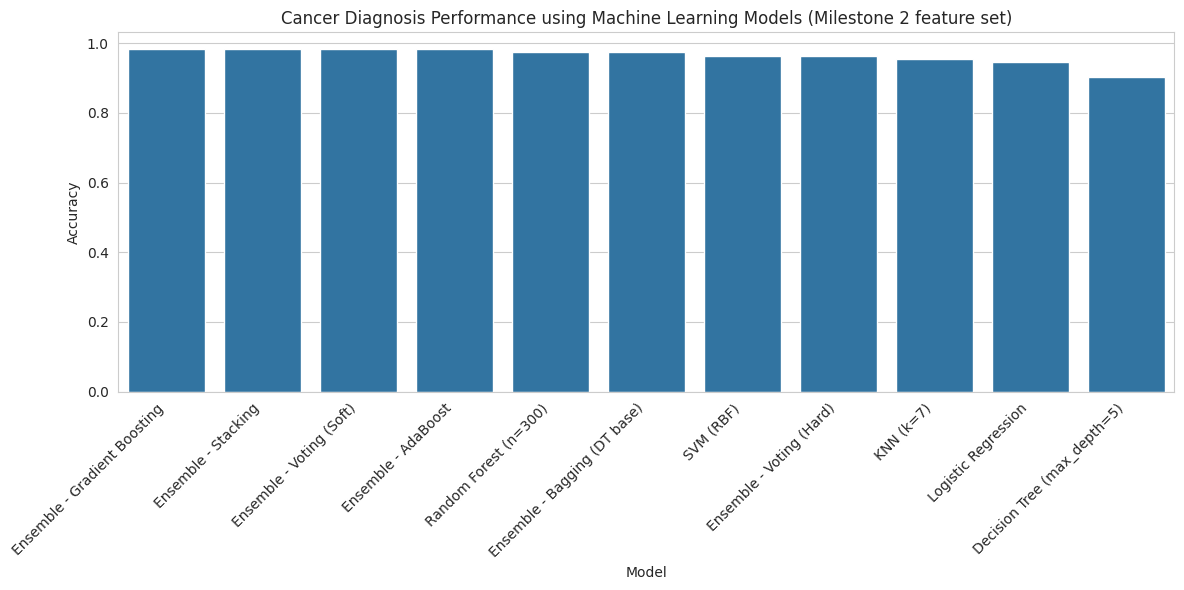

In [ ]:
accuracy_df = pd.DataFrame(results).T.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=accuracy_df.index, y=accuracy_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Cancer Diagnosis Performance using Machine Learning Models (Milestone 2 feature set)")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()